In [1]:
import pandas as pd 
import sklearn 

In [31]:
import pandas as pd

df = pd.read_csv(
    "spam.csv",
    sep=",",
    encoding="latin-1"
)


In [32]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [33]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


AttributeError: module 'matplotlib' has no attribute 'xlabel'

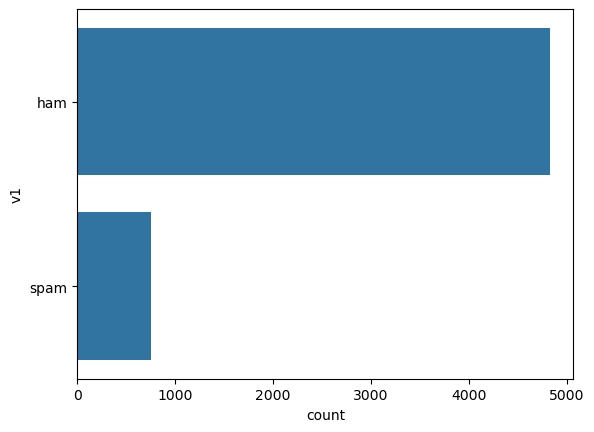

In [34]:
import matplotlib as plt 
import seaborn as sns
sns.countplot(df.v1)
plt.xlabel('Label')
plt.title('Number of ham and spam messages')

In [35]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [37]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_message'] = df['v2'].apply(preprocess)

In [38]:
df.head(2)

,v1,v2,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['clean_message']).toarray()
y = df['v1'].map({'ham':0, 'spam':1})

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Accuracy: 0.97847533632287
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       1.00      0.84      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [45]:
import pickle 
pickle.dump(nb_model, open("model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

In [48]:
tf_idf_pred = pickle.load(open("tfidf.pkl", "rb"))
model_pred = pickle.load(open("model.pkl", "rb"))

In [49]:
#Final Prediction Function
def predict_sms(text):
    text = preprocess(text)
    vector = tf_idf_pred.transform([text]).toarray()
    prediction = model_pred.predict(vector)
    
    return "Spam" if prediction[0] == 1 else "Not spam"

print(predict_sms("Congratulations! You have won a free lottery ticket"))

Not spam


In [ ]:
# #Final Prediction Function
# def predict_sms(text):
#     text = preprocess(text)
#     vector = tfidf.transform([text]).toarray()
#     prediction = nb_model.predict(vector)
    
#     return "Spam" if prediction[0] == 1 else "Ham"

# print(predict_sms("Congratulations! You have won a free lottery ticket"))